# **Install Dependencies**

In [1]:
!pip install tiktoken

In [2]:
! git clone https://github.com/karpathy/build-nanogpt.git nanogpt

fatal: destination path 'nanogpt' already exists and is not an empty directory.


# **Imports**

In [3]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import tiktoken
from dataclasses import dataclass
import numpy as np

import os
import psutil
import gc
import time


In [4]:
torch.manual_seed(1337)
if torch.cuda.is_available():
    torch.cuda.manual_seed(1337)


In [5]:
device = "cpu"
if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
print(f"using device: {device}")

using device: cuda


# **Model Definition**

The model is built from Andrej Karpathy's Nanogpt: https://github.com/karpathy/build-nanogpt.git  




In [6]:
class CausalSelfAttention(nn.Module):

    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        # key, query, value projections for all heads, but in a batch
        self.c_attn = nn.Linear(config.n_embd, 3 * config.n_embd)

        # output projection
        self.c_proj = nn.Linear(config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1

        # regularization
        self.n_head = config.n_head
        self.n_embd = config.n_embd

    def forward(self, x):
        B, T, C = x.size() # batch size, sequence length, embedding dimensionality (n_embd)
        # calculate query, key, values for all heads in batch and move head forward to be the batch dim
        # nh is "number of heads", hs is "head size", and C (number of channels) = nh * hs
        # e.g. in GPT-2 (124M), n_head=12, hs=64, so nh*hs=C=768 channels in the Transformer
        qkv = self.c_attn(x)
        q, k, v = qkv.split(self.n_embd, dim=2)
        k = k.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        q = q.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        v = v.view(B, T, self.n_head, C // self.n_head).transpose(1, 2) # (B, nh, T, hs)
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True) # flash attention
        y = y.transpose(1, 2).contiguous().view(B, T, C) # re-assemble all head outputs side by side

        # output projection
        y = self.c_proj(y)
        return y


In [7]:
class MLP(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd)
        self.gelu    = nn.GELU(approximate='tanh')
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd)
        self.c_proj.NANOGPT_SCALE_INIT = 1

    def forward(self, x):
        x = self.c_fc(x)
        x = self.gelu(x)
        x = self.c_proj(x)
        return x


In [8]:
class Block(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.ln_1 = nn.LayerNorm(config.n_embd)
        self.attn = CausalSelfAttention(config)
        self.ln_2 = nn.LayerNorm(config.n_embd)
        self.mlp = MLP(config)

    def forward(self, x):
        x = x + self.attn(self.ln_1(x))
        x = x + self.mlp(self.ln_2(x))
        return x


In [9]:
@dataclass
class GPTConfig:
    block_size: int = 1024 # max sequence length
    vocab_size: int = 50257 # number of tokens: 50,000 BPE merges + 256 bytes tokens + 1 <|endoftext|> token
    n_layer: int = 12 # number of layers
    n_head: int = 12 # number of heads
    n_embd: int = 768 # embedding dimension
    tie_weights: bool = True # Make weight tying as optional


In [10]:
class GPT(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # weight sharing scheme
        if config.tie_weights:
            self.transformer.wte.weight = self.lm_head.weight

        # init params
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.02
            if hasattr(module, 'NANOGPT_SCALE_INIT'):
                std *= (2 * self.config.n_layer) ** -0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        # idx is of shape (B, T)
        B, T = idx.size()
        assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"

        # forward the token and posisition embeddings
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (T, n_embd)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (B, T, n_embd)
        x = tok_emb + pos_emb

        # forward the blocks of the transformer
        for block in self.transformer.h:
            x = block(x)

        # forward the final layernorm and the classifier
        x = self.transformer.ln_f(x)

        # logits = self.lm_head(x) # (B, T, vocab_size)
        # loss = None
        # if targets is not None:
        #     loss = F.cross_entropy(
        #         logits.view(-1, logits.size(-1)),
        #         targets.view(-1)
        #     )
        # return logits, loss
        return x

    def configure_optimizers(self, weight_decay, learning_rate, device_type):
        # start with all of the candidate parameters (that require grad)
        param_dict = {pn: p for pn, p in self.named_parameters()}
        param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}
        # create optim groups. Any parameters that is 2D will be weight decayed, otherwise no.
        # i.e. all weight tensors in matmuls + embeddings decay, all biases and layernorms don't.
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]
        optim_groups = [
            {'params': decay_params, 'weight_decay': weight_decay},
            {'params': nodecay_params, 'weight_decay': 0.0}
        ]
        num_decay_params = sum(p.numel() for p in decay_params)
        num_nodecay_params = sum(p.numel() for p in nodecay_params)
        if master_process:
            print(f"num decayed parameter tensors: {len(decay_params)}, with {num_decay_params:,} parameters")
            print(f"num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params:,} parameters")
        # Create AdamW optimizer and use the fused version if it is available
        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and device_type == "cuda"
        if master_process:
            print(f"using fused AdamW: {use_fused}")
        optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=(0.9, 0.95), eps=1e-8, fused=use_fused)
        return optimizer

# **Model Instantiation**

## Model Configs

In [11]:
B = 2   # Batch Size
T = 128 # Seq Length

vocab_size = 50257
n_layer    = 4
n_head     = 4
n_embd     = 256

## Create a model and tokenizer

In [12]:
# Create a small model
config = GPTConfig(
    block_size=T,
    vocab_size=vocab_size,
    n_layer=n_layer,
    n_head=n_head,
    n_embd=n_embd
)
model = GPT(config)
model.to(device)

# Tokenizer
enc = tiktoken.get_encoding("gpt2")

# **Experiment 1: Shapes**

The input tokens have shape **[B,T]**. The Transformer maps each token position to a **D**-dimensional hidden representation, producing **[B,T,D]**. The language-model head projects each hidden representation into the vocabulary space, producing **[B,T,V]** logits. For next-token prediction, the final logit position has no corresponding target, so logits and targets are shifted to **[B,T-1,V]** and **[B,T-1]**. These are then flattened to **[B(T-1),V]** and **[B(T-1)]** for cross entropy.

In [13]:
text = "The cat sat on the mat"

# Tokenize the input text
tokens = enc.encode(text)
tokens = torch.tensor(tokens, dtype=torch.long)
print(f"Batch Size B=1, Input tokens T={tokens.shape}, Vocab V={vocab_size}\n")

# Add batch dimension before sending to model: [T] -> [1, T]
tokens = tokens.unsqueeze(0)
tokens = tokens.to(device)
print("tokens [B, T]:", tokens.shape)

# Forward pass
hidden = model(tokens)
print("hidden [B, T, D]:", hidden.shape)

# Output projection
logits = model.lm_head(hidden)
print("logits [B, T, V]:", logits.shape)

# Shift logits
shift_logits = logits[:, :-1, :]
shift_targets = tokens[:, 1:]
print("shift_logits [B, T-1, V]:", shift_logits.shape)
print("shift_targets [B, T-1]:", shift_targets.shape)

# Flatten for cross entropy
flat_logits = shift_logits.reshape(-1, vocab_size)
flat_targets = shift_targets.reshape(-1)
print("flat_logits [T-1, V]:", flat_logits.shape)
print("flat_targets [T-1]:", flat_targets.shape)

# Loss
loss = F.cross_entropy(flat_logits, flat_targets)
print("loss:", loss.item())

Batch Size B=1, Input tokens T=torch.Size([6]), Vocab V=50257

tokens [B, T]: torch.Size([1, 6])
hidden [B, T, D]: torch.Size([1, 6, 256])
logits [B, T, V]: torch.Size([1, 6, 50257])
shift_logits [B, T-1, V]: torch.Size([1, 5, 50257])
shift_targets [B, T-1]: torch.Size([1, 5])
flat_logits [T-1, V]: torch.Size([5, 50257])
flat_targets [T-1]: torch.Size([5])
loss: 10.827600479125977


# **Experiment 2: Shift verification**

The target at each position is the next token in the original sequence. Therefore, **logits[:, :-1]** and **tokens[:, 1:]** are correctly aligned for next-token prediction.

In [14]:
print("Position | Input token | Target token")
print("-" * 40)

for i in range(min(tokens.size(1), shift_targets.size(1))):
    input_token = enc.decode([tokens[0, i].item()])
    target_token = enc.decode([shift_targets[0, i].item()])

    print(f"{i:8d} | {input_token!r:12s} | {target_token!r}")

Position | Input token | Target token
----------------------------------------
       0 | 'The'        | ' cat'
       1 | ' cat'       | ' sat'
       2 | ' sat'       | ' on'
       3 | ' on'        | ' the'
       4 | ' the'       | ' mat'


# **Experiment 3: Padding mask**

Padding positions must not contribute to the language-model loss. We introduced a dedicated **<PAD>** token, created a binary loss mask aligned with the shifted targets, and verified that the number of contributing prediction positions decreases after masking. The masked loss is computed by summing only valid per-token losses and dividing by the number of valid tokens.  
There are 9 real tokens in the batch, but only 7 valid next-token prediction targets because each sequence loses its final position during the causal shift. The padded batch contains 10 possible prediction positions, of which 3 have <PAD> targets and are masked.

In [15]:
# GPT-2 tokenizer does not have a padding token. Introducing a padding token and creating the model again

PAD_ID = 50257
vocab_size = 50258

config = GPTConfig(
    block_size=T,
    vocab_size=vocab_size,
    n_layer=n_layer,
    n_head=n_head,
    n_embd=n_embd
)
model = GPT(config)
model.to(device)

print(f"Added Pad token to vocab")

Added Pad token to vocab


In [16]:
def get_padded_tokens(tokens, max_len):
    padded = torch.cat([
        tokens,
        torch.full((max_len - len(tokens),), PAD_ID, dtype=torch.long)
    ])
    return padded

In [17]:
# Inputs of different lengths
text1 = "The cat sat"
text2 = "The cat sat on the mat"

# Tokenize the inputs
tokens1 = torch.tensor(enc.encode(text1), dtype=torch.long)
tokens2 = torch.tensor(enc.encode(text2), dtype=torch.long)

# Pad them to the same length to create a batch
max_len = max(len(tokens1), len(tokens2))
padded1 = get_padded_tokens(tokens1, max_len)
padded2 = get_padded_tokens(tokens2, max_len)
print(f"\n{'PAD_ID':<20}: {PAD_ID}")
print(f"{'Max Seq length[T]':<20}: {max_len}")

print(f"\n{'input tokens1':20}: {tokens1}")
print(f"{'input tokens2':<20}: {tokens2}")
print(f"{'padded1 [T]':<20}: {padded1}")
print(f"{'padded2 [T]':<20}: {padded2}")

# Create a batch from padded tokens
batch_tokens = torch.stack([padded1, padded2])
batch_tokens = batch_tokens.to(device)
print(f"{'Batch [B, T]':<20}: {batch_tokens.shape}")

# Create the loss mask
attention_mask = (batch_tokens != PAD_ID)
loss_mask = attention_mask[:, 1:]

# Run the model
hidden = model(batch_tokens)
logits = model.lm_head(hidden)

# Shifted
shift_logits = logits[:, :-1, :]
shift_targets = batch_tokens[:, 1:]

# Flatten for cross entropy
flat_logits = shift_logits.reshape(-1, vocab_size)
flat_targets = shift_targets.reshape(-1)

per_token_loss = F.cross_entropy(
    flat_logits,
    flat_targets,
    reduction='none'
)

# Reshape loss to [B, T-1]
per_token_loss = per_token_loss.reshape(shift_targets.shape)
print(f"{'Loss shape [B, T-1]':<15} : {per_token_loss.shape}")

# Count the contributing tokens
valid_input_tokens = (batch_tokens != PAD_ID).sum().item()
total_prediction_positions = loss_mask.numel()
contributing_tokens = loss_mask.sum().item()
# print("Total possible predictions [T-1 x B] :", total_positions)
print("\nBefore padding/masking:")
print("  Valid input tokens: ", valid_input_tokens)
print("After batching + shift:")
print("  Total prediction positions [T-1 x B]: ", total_prediction_positions)
print("  Contributing target positions:", contributing_tokens)
print("  Masked/padding predictions:", int((loss_mask == 0).sum()))

# Calculate the masked loss
masked_loss = (
    per_token_loss * loss_mask
).sum() / loss_mask.sum()

print(f"\nUnmasked loss: {per_token_loss.mean()}")
print(f"Masked loss: {masked_loss.item()}")



PAD_ID              : 50257
Max Seq length[T]   : 6

input tokens1       : tensor([ 464, 3797, 3332])
input tokens2       : tensor([ 464, 3797, 3332,  319,  262, 2603])
padded1 [T]         : tensor([  464,  3797,  3332, 50257, 50257, 50257])
padded2 [T]         : tensor([ 464, 3797, 3332,  319,  262, 2603])
Batch [B, T]        : torch.Size([2, 6])
Loss shape [B, T-1] : torch.Size([2, 5])

Before padding/masking:
  Valid input tokens:  9
After batching + shift:
  Total prediction positions [T-1 x B]:  10
  Contributing target positions: 7
  Masked/padding predictions: 3

Unmasked loss: 10.667261123657227
Masked loss: 10.790876388549805


In [18]:
# Print the tokens and mask
for b in range(batch_tokens.size(0)):
    print(f"\nSequence {b}")

    for i in range(batch_tokens.size(1) - 1):
        input_id = batch_tokens[b, i].item()
        target_id = batch_tokens[b, i + 1].item()

        if input_id == PAD_ID:
            input_token = "<PAD>"
        else:
            input_token = enc.decode([input_id])

        if target_id == PAD_ID:
            target_token = "<PAD>"
        else:
            target_token = enc.decode([target_id])

        mask_value = int(loss_mask[b, i])

        print(
            f"{i:2d} | "
            f"{input_token!r:10s} → "
            f"{target_token!r:10s} | "
            f"loss_mask={mask_value}"
        )


Sequence 0
 0 | 'The'      → ' cat'     | loss_mask=1
 1 | ' cat'     → ' sat'     | loss_mask=1
 2 | ' sat'     → '<PAD>'    | loss_mask=0
 3 | '<PAD>'    → '<PAD>'    | loss_mask=0
 4 | '<PAD>'    → '<PAD>'    | loss_mask=0

Sequence 1
 0 | 'The'      → ' cat'     | loss_mask=1
 1 | ' cat'     → ' sat'     | loss_mask=1
 2 | ' sat'     → ' on'      | loss_mask=1
 3 | ' on'      → ' the'     | loss_mask=1
 4 | ' the'     → ' mat'     | loss_mask=1


# **Experiment 4: Document boundaries**

In [19]:
# GPT-2 tokenizer does not have a separator token either. Adding that as well, along with pad token

PAD_ID = 50257
SEP_ID = 50258
vocab_size = 50259

config = GPTConfig(
    block_size=T,
    vocab_size=vocab_size,
    n_layer=n_layer,
    n_head=n_head,
    n_embd=n_embd
)
model = GPT(config)
model.to(device)
print("Added pad token and doc separator token to vocab")

Added pad token and doc separator token to vocab


In [20]:
doc1 = "The cat sat on the mat."
doc2 = "Paris is the capital of France."

doc1_tokens = torch.tensor(enc.encode(doc1), dtype=torch.long)
doc2_tokens = torch.tensor(enc.encode(doc2), dtype=torch.long)
N1 = len(doc1_tokens)
N2 = len(doc2_tokens)
print(f"{'Document 1':<20}: {doc1_tokens}, Total {N1} tokens")
print(f"{'Document 2':<20}: {doc2_tokens}, Total {N2} tokens")

# Combine the docs with a separator
packed_tokens = torch.cat([
    doc1_tokens,
    torch.tensor([SEP_ID]),
    doc2_tokens
])

# Add batch dimension before sending to model: [T] -> [1, T]
packed_tokens = packed_tokens.unsqueeze(0).to(device)
print(f"{'tokens [B, T]':<20}:", packed_tokens.shape)

# Forward pass
hidden = model(packed_tokens)
print(f"{'hidden [B, T, D]':<20}:", hidden.shape)

# Output projection
logits = model.lm_head(hidden)
print(f"{'logits [B, T, V]':<20}:", logits.shape)

# Shift for next-token prediction
shift_inputs = packed_tokens[:, :-1]
shift_targets = packed_tokens[:, 1:]

# Calculate per token loss
flat_logits = logits[:, :-1, :].reshape(-1, vocab_size)
flat_targets = shift_targets.reshape(-1)
per_token_loss = F.cross_entropy(
    flat_logits,
    flat_targets,
    reduction='none'
)


# Build the Boundary mask
# After the shift, the target corresponding to the first token of doc B occurs at N1
boundary_mask = torch.ones_like(
    shift_targets,
    dtype=torch.float
)
boundary_position = N1

# Mask the prediction:  <SEP> -> first token of document 2
boundary_mask[:, boundary_position] = 0


# Print the masked and unmasked losses
unmasked_loss = per_token_loss.mean()
per_token_loss_2d = per_token_loss.reshape(shift_targets.shape)
masked_loss = (
    per_token_loss_2d * boundary_mask
).sum() / boundary_mask.sum()

print(f"\n{'Unmasked loss':<25}: {unmasked_loss.item():.6f}")
print(f"{'Boundary-masked loss':<25}: {masked_loss.item():.6f}")
print(f"{'Total prediction positions':<25}: {boundary_mask.numel()}")
print(f"{'Contributing loss terms':<25}: {boundary_mask.sum().item()}")

Document 1          : tensor([ 464, 3797, 3332,  319,  262, 2603,   13]), Total 7 tokens
Document 2          : tensor([40313,   318,   262,  3139,   286,  4881,    13]), Total 7 tokens
tokens [B, T]       : torch.Size([1, 15])
hidden [B, T, D]    : torch.Size([1, 15, 256])
logits [B, T, V]    : torch.Size([1, 15, 50259])

Unmasked loss            : 10.875654
Boundary-masked loss     : 10.874948
Total prediction positions: 14
Contributing loss terms  : 13.0


In [21]:
# Print the boundary table
print("\nPosition | Input       → Target      | Mask")
print("-" * 50)

for i in range(shift_inputs.size(1)):

    input_id = shift_inputs[0, i].item()
    target_id = shift_targets[0, i].item()

    if input_id == SEP_ID:
        input_token = "<SEP>"
    else:
        input_token = enc.decode([input_id])

    if target_id == SEP_ID:
        target_token = "<SEP>"
    else:
        target_token = enc.decode([target_id])

    mask_value = int(boundary_mask[0, i].item())

    print(
        f"{i:8d} | "
        f"{input_token!r:10s} → "
        f"{target_token!r:10s} | "
        f"{mask_value}"
    )


Position | Input       → Target      | Mask
--------------------------------------------------
       0 | 'The'      → ' cat'     | 1
       1 | ' cat'     → ' sat'     | 1
       2 | ' sat'     → ' on'      | 1
       3 | ' on'      → ' the'     | 1
       4 | ' the'     → ' mat'     | 1
       5 | ' mat'     → '.'        | 1
       6 | '.'        → '<SEP>'    | 1
       7 | '<SEP>'    → 'Paris'    | 0
       8 | 'Paris'    → ' is'      | 1
       9 | ' is'      → ' the'     | 1
      10 | ' the'     → ' capital' | 1
      11 | ' capital' → ' of'      | 1
      12 | ' of'      → ' France'  | 1
      13 | ' France'  → '.'        | 1


# Experiment 5: Perplexity

In [22]:
text = """
The cat sat on the mat.
The dog ran across the street.
The sun is shining today.
"""

# Get the tokens
tokens = enc.encode(text)
tokens = torch.tensor(tokens, dtype=torch.long)
tokens = tokens.unsqueeze(0).to(device)

# Forward pass
hidden = model(tokens)
logits = model.lm_head(hidden)

# Calculate next-token loss
shift_logits = logits[:, :-1, :]
shift_targets = tokens[:, 1:]

flat_logits = shift_logits.reshape(-1, vocab_size)
flat_targets = shift_targets.reshape(-1)

loss = F.cross_entropy(
    flat_logits,
    flat_targets
)

# Calculate perplexity
perplexity = torch.exp(loss)

print(f"{'Model vocabulary size':<25}: {vocab_size:,}")
print(f"{'Loss':<25}: {loss.item():.6f}")
print(f"{'Perplexity':<25}: {perplexity.item():,.2f}")
print(f"{'PPL / vocabulary size':<25}: {perplexity.item() / vocab_size:.3f}")
# print(f"Uniform-reference loss: {uniform_loss:.6f}")
# print(f"Uniform-reference PPL:  {uniform_ppl:.2f}")

Model vocabulary size    : 50,259
Loss                     : 10.742304
Perplexity               : 46,272.54
PPL / vocabulary size    : 0.921


# **Experiment 6: Tied vs Untied LM Head**

In [23]:
# Create tied model
tied_config = GPTConfig(
    block_size=T,
    vocab_size=vocab_size,
    n_layer=n_layer,
    n_head=n_head,
    n_embd=n_embd,
    tie_weights=True
)
tied_model = GPT(tied_config).to(device)

# Create untied model
untied_config = GPTConfig(
    block_size=T,
    vocab_size=vocab_size,
    n_layer=n_layer,
    n_head=n_head,
    n_embd=n_embd,
    tie_weights=False
)
untied_model = GPT(untied_config).to(device)


In [24]:
# Print metrics
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())


def parameter_count(tensor):
    return tensor.numel()

tied_embed_count = parameter_count(tied_model.transformer.wte.weight)
tied_lm_head_count = parameter_count(tied_model.lm_head.weight)
tied_total_count = count_parameters(tied_model)

untied_embed_count = parameter_count(untied_model.transformer.wte.weight)
untied_lm_head_count = parameter_count(untied_model.lm_head.weight)
untied_total_count = count_parameters(untied_model)

print(f"{'':<20} {'TIED':>10} {'UNTIED':>15}")
print(f"{'':<20} {'-':->10} {'-':->15}")
print(f"{'Embedding params  :':<20} {tied_embed_count:>10,} {untied_embed_count:>15,}")
print(f"{'LM head params    :':<20} {tied_lm_head_count:>10,} {untied_lm_head_count:>15,}")
print(f"{'Total model params:':<20} {tied_total_count:>10,} {untied_total_count:>15,}")

# Verify that the weights are actually shared
check_tied = tied_model.transformer.wte.weight.data_ptr() == tied_model.lm_head.weight.data_ptr()
check_untied = untied_model.transformer.wte.weight.data_ptr() == untied_model.lm_head.weight.data_ptr()
print(f"\nEmbedding/LM-head weights share storage:")
print(f"  Tied: {check_tied}")
print(f"  Untied: {check_untied}")

print(f"\nDifference between untied and tied params:")
print(f"  {untied_total_count - tied_total_count:,}")

                           TIED          UNTIED
                     ---------- ---------------
Embedding params  :  12,866,304      12,866,304
LM head params    :  12,866,304      12,866,304
Total model params:  16,058,624      28,924,928

Embedding/LM-head weights share storage:
  Tied: True
  Untied: False

Difference between untied and tied params:
  12,866,304


# **Experiment 7: Chunked Cross Entropy**

The hidden layer outputs are [B, T, D]. The LM head creates logits which are [B, T, V]. If we have:    
Batch       **B**  = 2  
Seq Length  **T** = 128  
Embed Dim   **D** = 256  
Vocab       **V** = 50,259  

Then logits are 2×128×50,259=12,866,304    
In FP32, thats approximately 12,866,304×4≈51.5 MB
During cross entropy, additional memory will be needed.





In [25]:
def chunked_cross_entropy(hidden, targets, lm_head, chunk_size=32):
    """
    Compute mean cross entropy without materializing
    the full [N, V] logits tensor.
    """

    total_loss = torch.zeros(
        (),
        device=hidden.device,
        dtype=hidden.dtype
    )

    total_tokens = 0

    for start in range(0, hidden.size(0), chunk_size):

        end = min(start + chunk_size, hidden.size(0))

        hidden_chunk = hidden[start:end]
        target_chunk = targets[start:end]

        # Only [chunk_size, V] logits exist at once
        logits_chunk = lm_head(hidden_chunk)

        # CE = logsumexp(logits) - correct_class_logit
        logsumexp = torch.logsumexp(
            logits_chunk,
            dim=-1
        )

        target_logits = logits_chunk.gather(
            1,
            target_chunk.unsqueeze(1)
        ).squeeze(1)

        chunk_loss = logsumexp - target_logits

        total_loss += chunk_loss.sum()
        total_tokens += target_chunk.numel()

    return total_loss / total_tokens

In [26]:
# Create some dummy inputs

B = 8
T = 128

tokens = torch.randint(
    0,
    vocab_size,
    (B, T),
    device=device
)


In [27]:
def memory_mb():
    return torch.cuda.max_memory_allocated() / (1024 ** 2)


def ordinary_ce(tokens):
    hidden = model(tokens)

    shift_hidden = hidden[:, :-1, :]
    shift_targets = tokens[:, 1:]

    flat_hidden = shift_hidden.reshape(-1, n_embd)
    flat_targets = shift_targets.reshape(-1)

    logits = model.lm_head(flat_hidden)

    loss = F.cross_entropy(
        logits,
        flat_targets
    )

    return loss


def chunked_ce(tokens, chunk_size=32):
    hidden = model(tokens)

    shift_hidden = hidden[:, :-1, :]
    shift_targets = tokens[:, 1:]

    flat_hidden = shift_hidden.reshape(-1, n_embd)
    flat_targets = shift_targets.reshape(-1)

    return chunked_cross_entropy(
        flat_hidden,
        flat_targets,
        model.lm_head,
        chunk_size=chunk_size
    )

## Correctness check

In [28]:
# Compare CE losses from both cases (chunked and ordinary)

with torch.inference_mode():
    ordinary_loss = ordinary_ce(tokens)
    chunked_loss = chunked_ce(tokens, chunk_size=32)

print(f"Ordinary CE: {ordinary_loss.item():.8f}")
print(f"Chunked CE:  {chunked_loss.item():.8f}")
print(f"Difference:  {abs(ordinary_loss.item() - chunked_loss.item()):.10f}")

Ordinary CE: 10.87849236
Chunked CE:  10.87849331
Difference:  0.0000009537


## Memory Consumption check - GPU

In [29]:
if device == "cuda":
    # Ordinary
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    with torch.inference_mode():
        ordinary_loss = ordinary_ce(tokens)

    torch.cuda.synchronize()

    ordinary_peak = torch.cuda.max_memory_allocated() / (1024 ** 2)


    # Chunked
    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    with torch.inference_mode():
        chunked_loss = chunked_ce(tokens, chunk_size=32)

    torch.cuda.synchronize()

    chunked_peak = torch.cuda.max_memory_allocated() / (1024 ** 2)


    # Results
    print(f"Ordinary CE: {ordinary_loss.item():.8f}")
    print(f"Chunked CE:  {chunked_loss.item():.8f}")
    print(f"Difference:  {abs(ordinary_loss.item() - chunked_loss.item()):.10f}")

    print(f"\nOrdinary CE peak memory: {ordinary_peak:.2f} MB")
    print(f"Chunked CE peak memory:  {chunked_peak:.2f} MB")
    print(f"Memory ratio:            {ordinary_peak / chunked_peak:.2f}x")

Ordinary CE: 10.87849236
Chunked CE:  10.87849331
Difference:  0.0000009537

Ordinary CE peak memory: 651.49 MB
Chunked CE peak memory:  274.62 MB
Memory ratio:            2.37x


# **Part 2: Extra head**

Instead of training the model only to predict the next token **\(t+1\)**, add a second head that predicts the token two positions ahead **\(t+2\)**.

## GPT classwith two heads

In [30]:
class GPTTwoHeads(nn.Module):

    def __init__(self, config):
        super().__init__()
        self.config = config

        self.transformer = nn.ModuleDict(dict(
            wte = nn.Embedding(config.vocab_size, config.n_embd),
            wpe = nn.Embedding(config.block_size, config.n_embd),
            h = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = nn.LayerNorm(config.n_embd),
        ))
        self.lm_head_1 = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # Adding a second head
        self.lm_head_2 = nn.Linear(config.n_embd, config.vocab_size, bias=False)

        # weight sharing scheme - only for original lm head
        if config.tie_weights:
            self.transformer.wte.weight = self.lm_head_1.weight

        # init params
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            std = 0.02
            if hasattr(module, 'NANOGPT_SCALE_INIT'):
                std *= (2 * self.config.n_layer) ** -0.5
            torch.nn.init.normal_(module.weight, mean=0.0, std=std)
            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        # idx is of shape (B, T)
        B, T = idx.size()
        assert T <= self.config.block_size, f"Cannot forward sequence of length {T}, block size is only {self.config.block_size}"

        # forward the token and posisition embeddings
        pos = torch.arange(0, T, dtype=torch.long, device=idx.device) # shape (T)
        pos_emb = self.transformer.wpe(pos) # position embeddings of shape (T, n_embd)
        tok_emb = self.transformer.wte(idx) # token embeddings of shape (B, T, n_embd)
        x = tok_emb + pos_emb

        # forward the blocks of the transformer
        for block in self.transformer.h:
            x = block(x)

        # forward the final layernorm and the classifier
        x = self.transformer.ln_f(x)
        return x

    def configure_optimizers(self, weight_decay, learning_rate, device_type):
        # start with all of the candidate parameters (that require grad)
        param_dict = {pn: p for pn, p in self.named_parameters()}
        param_dict = {pn: p for pn, p in param_dict.items() if p.requires_grad}
        # create optim groups. Any parameters that is 2D will be weight decayed, otherwise no.
        # i.e. all weight tensors in matmuls + embeddings decay, all biases and layernorms don't.
        decay_params = [p for n, p in param_dict.items() if p.dim() >= 2]
        nodecay_params = [p for n, p in param_dict.items() if p.dim() < 2]
        optim_groups = [
            {'params': decay_params, 'weight_decay': weight_decay},
            {'params': nodecay_params, 'weight_decay': 0.0}
        ]
        num_decay_params = sum(p.numel() for p in decay_params)
        num_nodecay_params = sum(p.numel() for p in nodecay_params)
        if master_process:
            print(f"num decayed parameter tensors: {len(decay_params)}, with {num_decay_params:,} parameters")
            print(f"num non-decayed parameter tensors: {len(nodecay_params)}, with {num_nodecay_params:,} parameters")
        # Create AdamW optimizer and use the fused version if it is available
        fused_available = 'fused' in inspect.signature(torch.optim.AdamW).parameters
        use_fused = fused_available and device_type == "cuda"
        if master_process:
            print(f"using fused AdamW: {use_fused}")
        optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=(0.9, 0.95), eps=1e-8, fused=use_fused)
        return optimizer

## Create GPT model with two heads

In [31]:
# Create a model
config = GPTConfig(
    block_size=T,
    vocab_size=vocab_size,
    n_layer=n_layer,
    n_head=n_head,
    n_embd=n_embd,
    tie_weights=False
)
model = GPTTwoHeads(config).to(device)



## Check Loss from two LM heads

In [32]:
text = "The cat sat on the mat"

# Tokenize the input text
tokens = enc.encode(text)
tokens = torch.tensor(tokens, dtype=torch.long)

# Add batch dimension before sending to model: [T] -> [1, T]
tokens = tokens.unsqueeze(0).to(device)

# Forward pass: [B,T,D]
hidden = model(tokens)

# Calculate two sets of logits from LM head: [B,T,V]
logits_t1 = model.lm_head_1(hidden)
logits_t2 = model.lm_head_2(hidden)

# Create two targets, for t+1 and t+2
shift_targets_t1 = tokens[:, 1:]
shift_targets_t2 = tokens[:, 2:]

# Align the logits with the targets for t+1 and t+2
shift_logits_t1 = logits_t1[:, :-1, :]
shift_logits_t2 = logits_t2[:, :-2, :]

# Calculate both losses
loss_t1 = F.cross_entropy(
    shift_logits_t1.reshape(-1, vocab_size),
    shift_targets_t1.reshape(-1)
)

loss_t2 = F.cross_entropy(
    shift_logits_t2.reshape(-1, vocab_size),
    shift_targets_t2.reshape(-1)
)

# Final loss
total_loss = loss_t1 + loss_t2

print("hidden:", hidden.shape)
print("t+1 logits:", logits_t1.shape)
print("t+2 logits:", logits_t2.shape)

print("t+1 targets:", tokens[:, 1:].shape)
print("t+2 targets:", tokens[:, 2:].shape)

print(f"t+1 loss: {loss_t1.item():.6f}")
print(f"t+2 loss: {loss_t2.item():.6f}")
print(f"Total loss: {(loss_t1 + loss_t2).item():.6f}")

hidden: torch.Size([1, 6, 256])
t+1 logits: torch.Size([1, 6, 50259])
t+2 logits: torch.Size([1, 6, 50259])
t+1 targets: torch.Size([1, 5])
t+2 targets: torch.Size([1, 4])
t+1 loss: 11.055297
t+2 loss: 10.865934
Total loss: 21.921230


## Check t+1 and t+2 target tokens alignment

In [33]:
print("\nt+1 predictions:")

print("Position | Input token | Target token")
print("-" * 40)
for i in range(min(tokens.size(1), shift_targets_t1.size(1))):
    input_token = enc.decode([tokens[0, i].item()])
    target_token = enc.decode([shift_targets_t1[0, i].item()])

    print(f"{i:8d} | {input_token!r:12s} | {target_token!r}")


print("\nt+2 predictions:")

print("Position | Input token | Target token")
print("-" * 40)
for i in range(min(tokens.size(1), shift_targets_t2.size(1))):
    input_token = enc.decode([tokens[0, i].item()])
    target_token = enc.decode([shift_targets_t2[0, i].item()])

    print(f"{i:8d} | {input_token!r:12s} | {target_token!r}")



t+1 predictions:
Position | Input token | Target token
----------------------------------------
       0 | 'The'        | ' cat'
       1 | ' cat'       | ' sat'
       2 | ' sat'       | ' on'
       3 | ' on'        | ' the'
       4 | ' the'       | ' mat'

t+2 predictions:
Position | Input token | Target token
----------------------------------------
       0 | 'The'        | ' sat'
       1 | ' cat'       | ' on'
       2 | ' sat'       | ' the'
       3 | ' on'        | ' mat'


## **Training loop with two LM heads**

Overall flow:

```

        tokens  
          ↓  
      GPTTwoHeads   
          ↓   
        hidden   
          ↓   
   ├───────────────┐    
   ↓               ↓    
t+1 head         t+2 head   
   ↓               ↓   
logits_t1        logits_t2    
   ↓               ↓    
CE(t+1)          CE(t+2)    
   └───────┬───────┘    
           ↓    
     total_loss    
     = loss_t1 + loss_t2   
           ↓    
       backward()    
           ↓    
       optimizer
```

The same backward pass updates the shared Transformer and both heads.  



### **Create training batches from input file**

In [34]:
# Read data
with open("nanogpt/input.txt", "r") as f:
    text = f.read()

data = torch.tensor(
    enc.encode(text),
    dtype=torch.long
)

def get_batch(data, B, T):
    ix = torch.randint(
        0,
        len(data) - T - 2,
        (B,)
    )

    x = torch.stack([
        data[i:i+T]
        for i in ix
    ])

    return x.to(device)


### **Create model, optimizer**

In [35]:
B = 8
T = 128

two_head_model = GPTTwoHeads(config).to(device)

optimizer = torch.optim.AdamW(
    two_head_model.parameters(),
    lr=3e-4
)

# Fixed eval batch
eval_tokens = get_batch(data, B, T)

In [36]:
# Eval function
def eval_function(two_head_model, eval_tokens, hidden, vocab_size):
    two_head_model.eval()

    with torch.inference_mode():
        hidden = two_head_model(eval_tokens)

        logits_t1 = two_head_model.lm_head_1(hidden)
        logits_t2 = two_head_model.lm_head_2(hidden)

        eval_loss_t1 = F.cross_entropy(
            logits_t1[:, :-1, :].reshape(-1, vocab_size),
            eval_tokens[:, 1:].reshape(-1)
        )

        eval_loss_t2 = F.cross_entropy(
            logits_t2[:, :-2, :].reshape(-1, vocab_size),
            eval_tokens[:, 2:].reshape(-1)
        )

    two_head_model.train()
    return eval_loss_t1, eval_loss_t2

### **Training**

In [37]:
num_steps = 1000

train_loss_t1 = []
train_loss_t2 = []
train_loss_total = []

two_head_model.train()

# Loop
for step in range(num_steps):
    tokens = get_batch(data, B, T)

    # Forward pass
    hidden = two_head_model(tokens)

    # t+1 prediction
    logits_t1 = two_head_model.lm_head_1(hidden)
    loss_t1 = F.cross_entropy(
        logits_t1[:, :-1, :].reshape(-1, vocab_size),
        tokens[:, 1:].reshape(-1)
    )

    # t+2 prediction
    logits_t2 = two_head_model.lm_head_2(hidden)
    loss_t2 = F.cross_entropy(
        logits_t2[:, :-2, :].reshape(-1, vocab_size),
        tokens[:, 2:].reshape(-1)
    )

    # Total loss
    total_loss = loss_t1 + loss_t2

    # Back prop
    optimizer.zero_grad(set_to_none=True)
    total_loss.backward()
    optimizer.step()

    # Saving losses
    train_loss_t1.append(loss_t1.item())
    train_loss_t2.append(loss_t2.item())
    train_loss_total.append(total_loss.item())

    if step % 100 == 0:
        # Run eval loop
        eval_loss_t1, eval_loss_t2 = eval_function(
            two_head_model, eval_tokens, hidden, vocab_size
        )
        print(
            f"step {step:4d} | "
            f"t+1: {loss_t1.item():.4f} | "
            f"t+2: {loss_t2.item():.4f} | "
            f"total: {total_loss.item():.4f} | "
            f"eval t+1: {eval_loss_t1.item():.4f} | "
            f"eval t+2: {eval_loss_t2.item():.4f}"
        )




step    0 | t+1: 10.8807 | t+2: 10.8854 | total: 21.7661 | eval t+1: 10.5245 | eval t+2: 10.6075
step  100 | t+1: 6.2512 | t+2: 6.4294 | total: 12.6806 | eval t+1: 6.2274 | eval t+2: 6.4398
step  200 | t+1: 5.4262 | t+2: 5.8361 | total: 11.2623 | eval t+1: 5.6680 | eval t+2: 6.0904
step  300 | t+1: 5.2997 | t+2: 5.8856 | total: 11.1853 | eval t+1: 5.3530 | eval t+2: 5.9058
step  400 | t+1: 5.1230 | t+2: 5.7454 | total: 10.8684 | eval t+1: 5.0452 | eval t+2: 5.6938
step  500 | t+1: 4.6655 | t+2: 5.3512 | total: 10.0167 | eval t+1: 4.8260 | eval t+2: 5.5184
step  600 | t+1: 4.8585 | t+2: 5.6595 | total: 10.5180 | eval t+1: 4.6933 | eval t+2: 5.4221
step  700 | t+1: 3.8107 | t+2: 4.6647 | total: 8.4754 | eval t+1: 4.5637 | eval t+2: 5.3237
step  800 | t+1: 4.0159 | t+2: 4.8774 | total: 8.8933 | eval t+1: 4.4925 | eval t+2: 5.2529
step  900 | t+1: 3.9921 | t+2: 4.8760 | total: 8.8681 | eval t+1: 4.3972 | eval t+2: 5.2118


In [38]:
print("\nFinal losses:")
print(f"t+1 loss: {train_loss_t1[-1]:.6f}")
print(f"t+2 loss: {train_loss_t2[-1]:.6f}")
print(f"total:    {train_loss_total[-1]:.6f}")

print("\nLoss reduction:")
print(f"t+1: {train_loss_t1[0]:.4f} → {train_loss_t1[-1]:.4f}")
print(f"t+2: {train_loss_t2[0]:.4f} → {train_loss_t2[-1]:.4f}")

# for i in range(tokens.size(1) - 2):
#     print(
#         f"{enc.decode([tokens[0,i].item()])!r:10s} "
#         f"→ t+1: {enc.decode([tokens[0,i+1].item()])!r:10s} "
#         f"→ t+2: {enc.decode([tokens[0,i+2].item()])!r}"
#     )


Final losses:
t+1 loss: 4.574419
t+2 loss: 5.406036
total:    9.980455

Loss reduction:
t+1: 10.8807 → 4.5744
t+2: 10.8854 → 5.4060


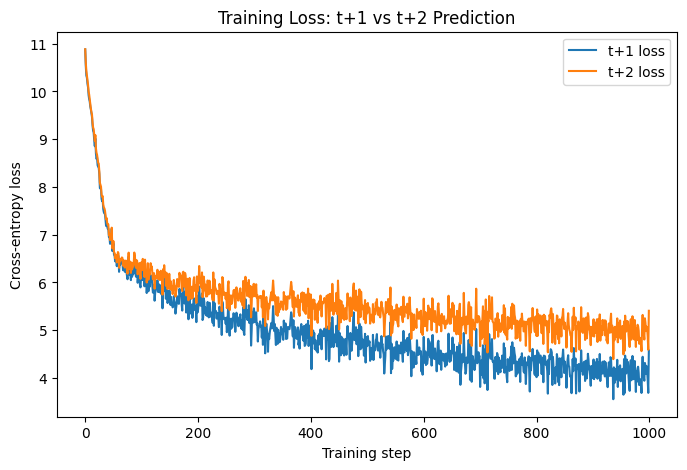

In [39]:
# Plotting loss

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_loss_t1, label="t+1 loss")
plt.plot(train_loss_t2, label="t+2 loss")

plt.xlabel("Training step")
plt.ylabel("Cross-entropy loss")
plt.title("Training Loss: t+1 vs t+2 Prediction")

plt.legend()
plt.show()